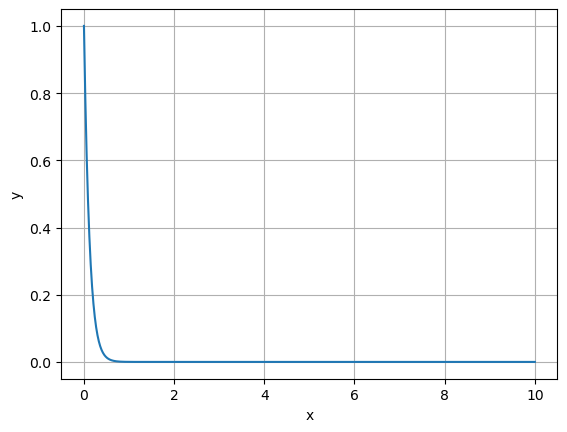

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

with open("/Users/samuelvanderswaluw/Library/CloudStorage/OneDrive-HvA/project blok 4 leerjaar 1/versnellingsprofiel_scherp.csv") as bestand:
    inhoud = bestand.read()

k = 10
m = 2
c1 = 1
c2 = 2

x, y =0, 2
def y_baan(x):
    return (c1+c2*x)*np.exp((-k/2*m)*x)

x = np.linspace(0, 10, 1000)
y = y_baan(x)


plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

Massa:0.03616071428571429
Resultaten opgeslagen als resultaten_sensor.csv


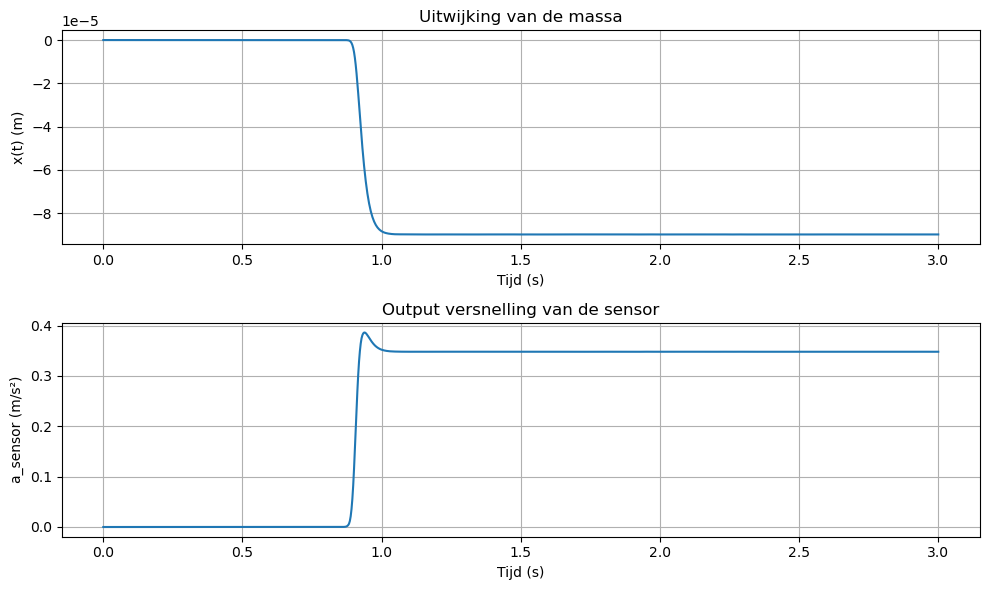

In [3]:
# Auteurs: Samuel van der Swaluw en Jobbe Mei
# Datum: 24-05-2026

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# PARAMETERS

k = 140            # veerconstante [N/m]
c = 4.5            # dempingsconstante [Ns/m]
m = (c**2)/(4*k)   # massa [kg]
print(f"Massa:{m}")

# CSV BESTAND INLEZEN
# CSV moet kolommen bevatten:
# tijd, versnelling

data = pd.read_csv("data/versnellingsprofiel_scherp.csv")

t_data = data["# tijd (s)"].values
a_data = data[" versnelling (m/s^2)"].values

# Interpolatiefunctie voor a(t)
a_t = interp1d(t_data, a_data, fill_value="extrapolate")

# y[0] = x      -> uitwijking
# y[1] = x_dot  -> snelheid

def systeem(t, y):

    x = y[0]
    x_dot = y[1]

    # externe versnelling uit CSV
    a_external = a_t(t)

    # tweede orde differentiaalvergelijking
    x_ddot = (-c * x_dot - k * x - m * a_t(t)) / m
    a_sensor = x_ddot + a_t(t)

    return [x_dot, x_ddot]

y0 = [0, 0]   # begin uitwijking en snelheid

# NUMERIEKE OPLOSSING
t_end = t_data[-1]
t_sim = np.linspace(t_data[0], t_end, 1000)

oplossing = solve_ivp(
    systeem,
    [t_data[0], 10],
    y0,
    t_eval=t_sim
)

t = oplossing.t
x = oplossing.y[0]
x_dot = oplossing.y[1]

# sensorsversnelling berekenen
a_sensor = (-c * x_dot - k * x) / m

# OPSLAAN ALS CSV
resultaten = pd.DataFrame({
    "tijd": t,
    "uitwijking": x,
    "sensor_versnelling": a_sensor
})
resultaten.to_csv("data/resultaten_sensor.csv", index=False)

print("Resultaten opgeslagen als resultaten_sensor.csv")

#Ploten
plt.figure(figsize=(10, 6))

# Uitwijking
plt.subplot(2, 1, 1)
plt.plot(t, x)
plt.title("Uitwijking van de massa")
plt.xlabel("Tijd (s)")
plt.ylabel("x(t) (m)")
plt.grid()

# Sensorversnelling
plt.subplot(2, 1, 2)
plt.plot(t, a_sensor)
plt.title("Output versnelling van de sensor")
plt.xlabel("Tijd (s)")
plt.ylabel("a_sensor (m/s²)")
plt.grid()

plt.tight_layout()
plt.show()

#Ai statement:
#Regels 26,27 en 32 t/m 46 zijn geschreven door chatgpt 3.5
#Prompt die daarvoor gebruikt zijn: Hoe kan deze code aangepast worden zodat hij de data uit het csv bestand gebruikt voor de differentiaalvergelijking?